In [1]:
%pip install tabulate graphviz

Note: you may need to restart the kernel to use updated packages.


In [2]:
from torch import nn
import torch
import torch.nn.functional as F
import numpy as np

IMG_H=np.short(512)
IMG_W=np.short(512)
IMG_C=np.short(3)

In [3]:
from pytorch_nndct.apis import Inspector

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'

[VAIQ_NOTE]: Loading NNDCT kernels...


In [4]:
class CNetPlusScalar_simple_noback(nn.Module):
    """
    CNetPlusScalar inherits from CNet but rewrites the forward method by introducing a scalar value to the output.
    The difference is that x is now a dictionary with the key 'image' and 'scalar'.
    old CNN applicable to 512x512 images
    """
    def __init__(self):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2) 
        self.conv1 = nn.Conv2d(IMG_C, 3, 5) 
        self.conv2 = nn.Conv2d(3, 3, 3) 
        self.conv3 = nn.Conv2d(3, 3, 3) 
        self.conv4 = nn.Conv2d(3, 3, 3)
        self.conv5 = nn.Conv2d(3, 3, 3)
        self.conv6 = nn.Conv2d(3, 3, 3)
        self.conv7 = nn.Conv2d(3, 3, 3)
        self.fc1 = nn.Linear(3 * 2 * 2, 30)
        self.fc2 = nn.Linear(30, 30)
        self.fc3 = nn.Linear(30, 1)

    def forward(self, image, vector=None):
        x = self.pool(F.relu(self.conv1(image))) 
        x = self.pool(F.relu(self.conv2(x))) 
        x = self.pool(F.relu(self.conv3(x))) 
        x = self.pool(F.relu(self.conv4(x))) 
        x = self.pool(F.relu(self.conv5(x)))
        x = self.pool(F.relu(self.conv6(x)))
        x = self.pool(F.relu(self.conv7(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [5]:
# Specify a target name or fingerprint you want to deploy on
target = "DPUCZDX8G_ISA1_B4096"
# Initialize inspector with target
inspector = Inspector(target)


[VAIQ_NOTE]: =>Inspector is initialized successfully with target:
name: DPUCZDX8G_ISA1_B4096
type: DPUCZDX8G
isa_version: 1


In [6]:
# Start to inspect the float model
# Note: visualization of inspection results relies on the dot engine.If you don't install dot successfully, set 'image_format = None' when inspecting.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNetPlusScalar_simple_noback()
# model.load_state_dict(torch.load('pre_trained_weights.pt'), strict=True)
dummy_input = torch.randn(1, IMG_C, IMG_H, IMG_W)
inspector.inspect(model, (dummy_input,), device=device, output_dir="inspect", image_format="png") 


[VAIQ_NOTE]: =>Start to inspect model...

[VAIQ_NOTE]: =>Quant Module is in 'cpu'.

[VAIQ_NOTE]: =>Parsing CNetPlusScalar_simple_noback...

[VAIQ_NOTE]: Start to trace model...

[VAIQ_NOTE]: Finish tracing.

[VAIQ_NOTE]: Processing ops...


██████████████████████████████████████████████████| 29/29 [00:00<00:00, 2424.84it/s, OpInfo: name = return_0, type = Return]           


[VAIQ_NOTE]: =>Doing weights equalization...

[VAIQ_NOTE]: =>Quantizable module is generated.(inspect/CNetPlusScalar_simple_noback.py)

[VAIQ_NOTE]: All the operators are assigned to the DPU(see more details in 'inspect/inspect_DPUCZDX8G_ISA1_B4096.txt')



[VAIQ_NOTE]: Dot image is generated.(inspect/inspect_DPUCZDX8G_ISA1_B4096.png)

[VAIQ_NOTE]: =>Finish inspecting.


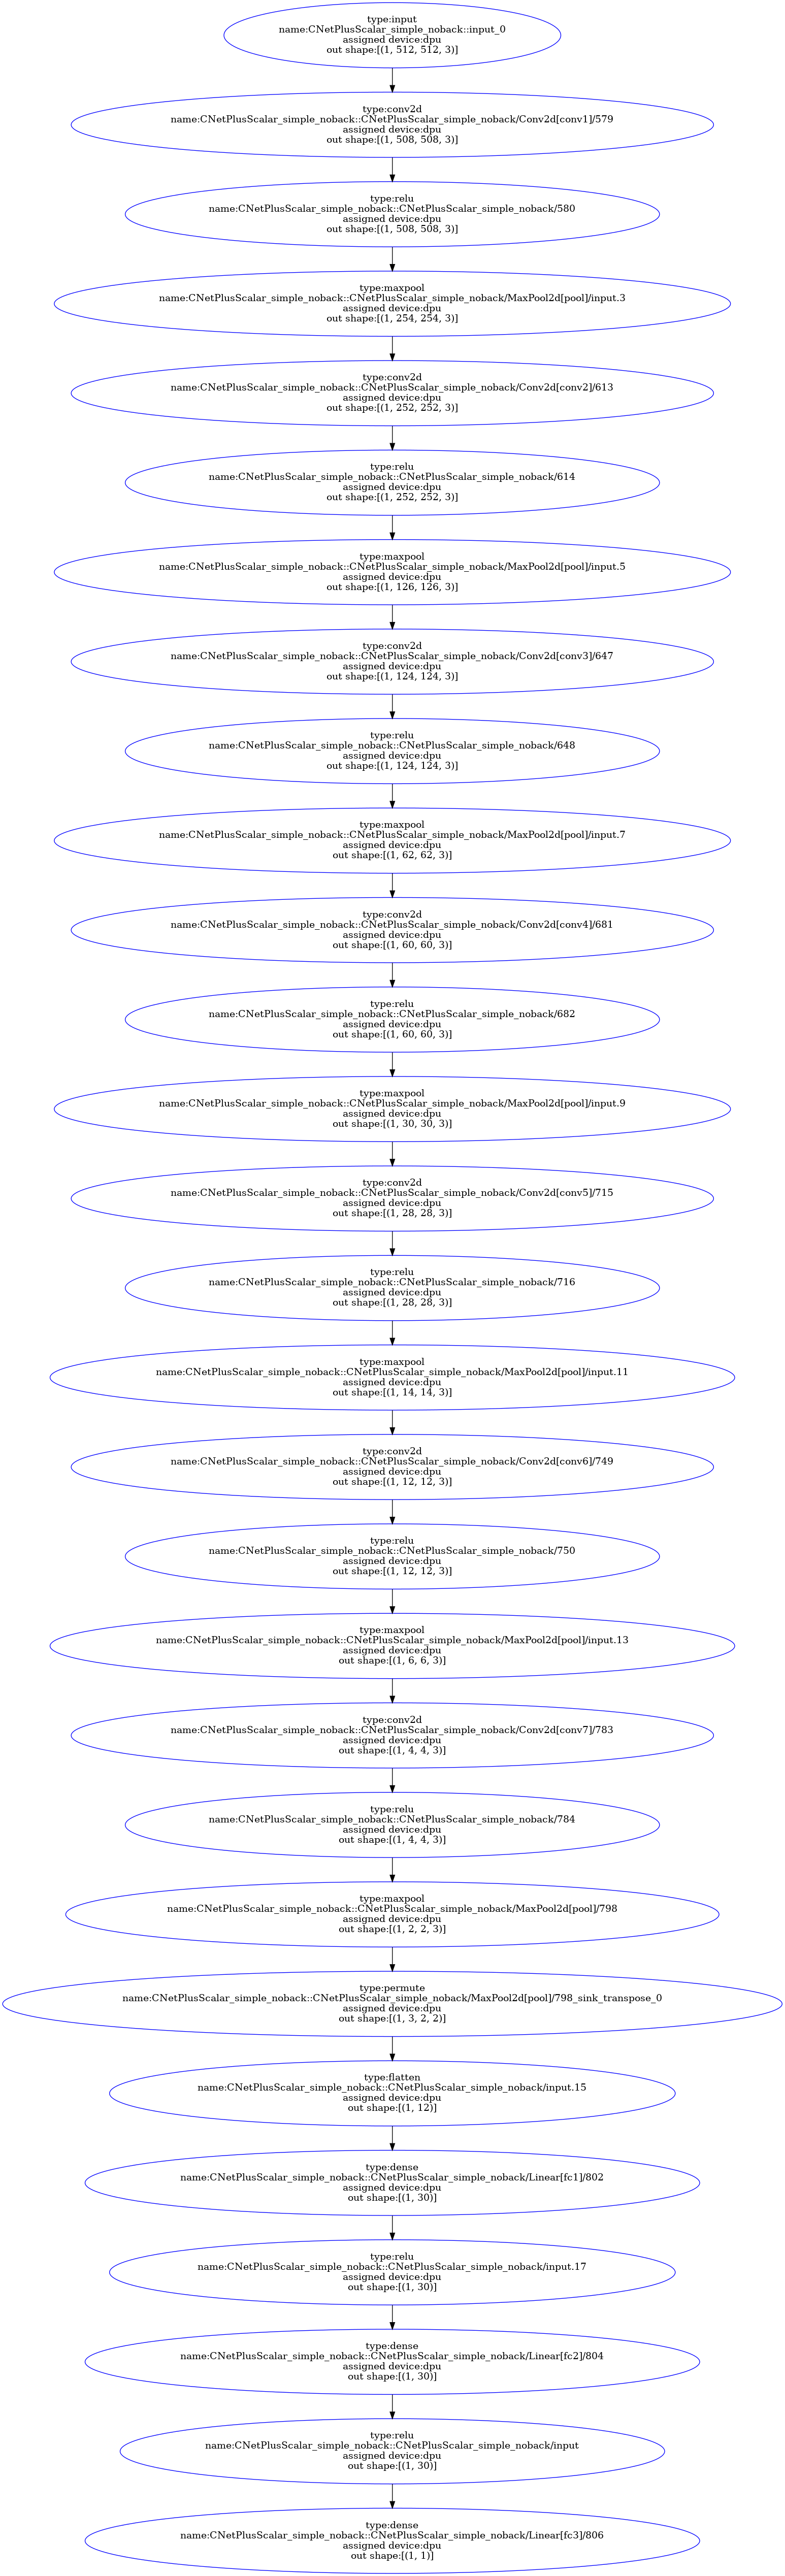

In [7]:
# Show the dot image
from IPython.display import Image
Image(f'inspect/inspect_{target}.png')

In [8]:
input = torch.randn([1, 3, IMG_H, IMG_W], dtype=torch.float32).to(device)

In [9]:
from pytorch_nndct.apis import torch_quantizer

quant_dir = "./V2_5/"
model = CNetPlusScalar_simple_noback()

quantizer = torch_quantizer('calib', model, (input), output_dir = quant_dir, device=device)
model = quantizer.quant_model

model.eval()
test = model(input)

quantizer.export_quant_config()

model = CNetPlusScalar_simple_noback()
quantizer = torch_quantizer('test', model, (input), output_dir = quant_dir, device=device)
model = quantizer.quant_model

model.eval()
test = model(input)

quantizer.export_xmodel(quant_dir, deploy_check=True)
#quantizer.export_torch_script(output_dir=quant_dir)
quantizer.export_onnx_model(output_dir=quant_dir)


[VAIQ_NOTE]: Quant config file is empty, use default quant configuration

[VAIQ_NOTE]: Quantization calibration process start up...

[VAIQ_NOTE]: =>Quant Module is in 'cpu'.

[VAIQ_NOTE]: =>Parsing CNetPlusScalar_simple_noback...

[VAIQ_NOTE]: Start to trace model...

[VAIQ_NOTE]: Finish tracing.

[VAIQ_NOTE]: Processing ops...


██████████████████████████████████████████████████| 29/29 [00:00<00:00, 3656.32it/s, OpInfo: name = return_0, type = Return]           


[VAIQ_NOTE]: =>Doing weights equalization...

[VAIQ_NOTE]: =>Quantizable module is generated.(./V2_5/CNetPlusScalar_simple_noback.py)

[VAIQ_NOTE]: =>Get module with quantization.

[VAIQ_NOTE]: =>Exporting quant config.(./V2_5//quant_info.json)

[VAIQ_NOTE]: Quant config file is empty, use default quant configuration

[VAIQ_NOTE]: Quantization test process start up...

[VAIQ_NOTE]: =>Quant Module is in 'cpu'.

[VAIQ_NOTE]: =>Parsing CNetPlusScalar_simple_noback...

[VAIQ_NOTE]: Start to trace model...

[VAIQ_NOTE]: Finish tracing.

[VAIQ_NOTE]: Processing ops...



██████████████████████████████████████████████████| 29/29 [00:00<00:00, 2810.09it/s, OpInfo: name = return_0, type = Return]           


[VAIQ_NOTE]: =>Doing weights equalization...

[VAIQ_NOTE]: =>Quantizable module is generated.(./V2_5/CNetPlusScalar_simple_noback.py)

[VAIQ_NOTE]: =>Get module with quantization.



[VAIQ_NOTE]: =>Converting to xmodel ...

[VAIQ_NOTE]: =>Dumping 'CNetPlusScalar_simple_noback'' checking data...

[VAIQ_NOTE]: =>Finsh dumping data.(./V2_5/deploy_check_data_int/CNetPlusScalar_simple_noback)

[VAIQ_NOTE]: =>Successfully convert 'CNetPlusScalar_simple_noback' to xmodel.(./V2_5/CNetPlusScalar_simple_noback_int.xmodel)


/opt/vitis_ai/conda/envs/vitis-ai-pytorch/lib/python3.7/site-packages/pytorch_nndct/nn/modules/prim_ops.py:107: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if not (self.node.out_tensors[0].shape[1:] == list(input.size())[1:]):


In [10]:
!vai_c_xir --xmodel ./V2_5/CNetPlusScalar_simple_noback_int.xmodel --arch /opt/vitis_ai/compiler/arch/DPUCZDX8G/ZCU104/arch.json --output_dir ./V2_5 --net_name zcu104_CNet

**************************************************
* VITIS_AI Compilation - Xilinx Inc.
**************************************************
[UNILOG][INFO] Compile mode: dpu
[UNILOG][INFO] Debug mode: function
[UNILOG][INFO] Target architecture: DPUCZDX8G_ISA1_B4096
[UNILOG][INFO] Graph name: CNetPlusScalar_simple_noback, with op num: 87
[UNILOG][INFO] Begin to compile...
[UNILOG][INFO] Total device subgraph number 3, DPU subgraph number 1
[UNILOG][INFO] Compile done.
[UNILOG][INFO] The meta json is saved to "/workspace/my_work/PyNet/./V2_5/meta.json"
[UNILOG][INFO] The compiled xmodel is saved to "/workspace/my_work/PyNet/./V2_5/zcu104_CNet.xmodel"
[UNILOG][INFO] The compiled xmodel's md5sum is 160a0d51c742fc96ce022955797c74b1, and has been saved to "/workspace/my_work/PyNet/./V2_5/md5sum.txt"
